In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import calendar

Load Dataset

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
print("Shape of train data: ", df_train.shape)
print("Shape of test data: ", df_test.shape)

Shape of train data:  (1460, 81)
Shape of test data:  (1459, 80)


In [4]:
# df_train.isnull().sum()
df_train.isna().sum().sum()

np.int64(7829)

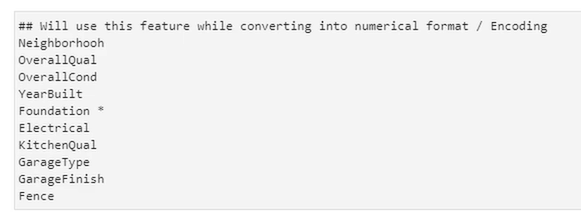

Data Integration


In [5]:
df = pd.concat([df_train, df_test])
print("Shape of combined data:",df.shape)

Shape of combined data: (2919, 81)


In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [7]:
null_vaue = df.isnull().sum()/df.shape[0] * 100
null_vaue

Id                0.000000
MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.034258
SaleCondition     0.000000
SalePrice        49.982871
Length: 81, dtype: float64

In [8]:
drop_col = null_vaue[null_vaue > 20].keys()
drop_col

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature',
       'SalePrice'],
      dtype='object')

<Axes: xlabel='MSSubClass', ylabel='Density'>

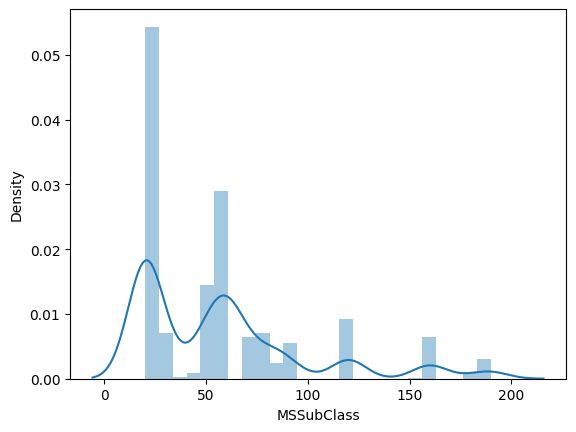

In [9]:
sns.distplot(df['MSSubClass'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

Most Null value features

Alley
FireplaceQu
PoolQC
Fence
MiscFeature

In [11]:
int_feature = df.select_dtypes(include=['int64']).columns
print(f"Total number of integer features: int_feature.shape[0]")
print("Integer Features:",int_feature.tolist())

Total number of integer features: int_feature.shape[0]
Integer Features: ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [12]:
float_feature = df.select_dtypes(include=['float64']).columns
print(f"Total number of Float features: float_feature.shape[0]")
print("Float Features:",float_feature.tolist())

Total number of Float features: float_feature.shape[0]
Float Features: ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']


In [13]:
ob_feature = df.select_dtypes(include=['object']).columns
print(f"Total number of object features: ob_feature.shape[0]")
print("Object Features:",ob_feature.tolist())

Total number of object features: ob_feature.shape[0]
Object Features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## Get the Statistical Information of NumericalFeatures

In [14]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,...,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,...,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,...,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [15]:
df.describe().shape

(8, 38)

## Handling Missing Values 


Visualize Null/Missing Values

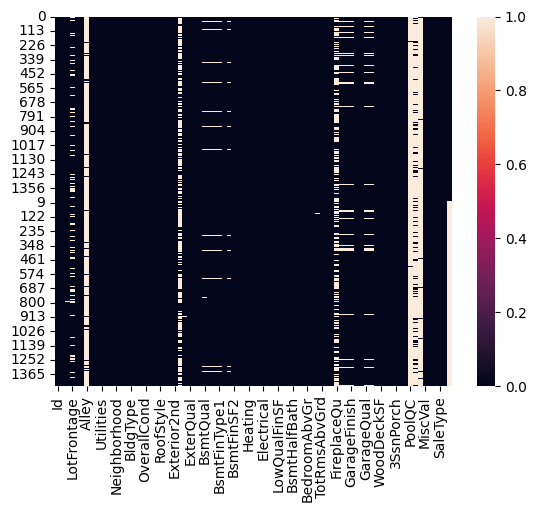

In [16]:
import os

plt.Figure(figsize=(10,6))
sns.heatmap(df.isnull())
output_dir = r"E:\House Prise Prediction\EDA"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "heatmap.png"))
plt.show()

## Get the null value  percentage for every feature 

In [17]:
df.set_index("Id", inplace=True)

In [18]:
null_value =  df.isnull().sum()
null_value


MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
                 ... 
MoSold              0
YrSold              0
SaleType            1
SaleCondition       0
SalePrice        1459
Length: 80, dtype: int64

In [19]:
null_value_per =  null_value/df.shape[0] * 100
null_value_per


MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.034258
SaleCondition     0.000000
SalePrice        49.982871
Length: 80, dtype: float64

## Drop Columns / Features

As per Observation we will not drop any feature from data

In [20]:
""""As Per Domain Knowledge we will not drop those feature, instad None value we will add constant value as "NA """
Null_val_50_pr = null_value_per[null_value_per > 50]
Null_val_50_pr

Alley          93.216855
MasVnrType     60.500171
PoolQC         99.657417
Fence          80.438506
MiscFeature    96.402878
dtype: float64

In [21]:
""""As Per Domain Knowledge we will not drop those feature, instad None value we will add constant value as "NA """
Null_val_20_50_pr = null_value_per[(null_value_per > 20) & (null_value_per < 50)]
Null_val_20_50_pr

FireplaceQu    48.646797
SalePrice      49.982871
dtype: float64

In [22]:
""""As Per Domain Knowledge we will not drop those feature, instad None value we will add constant value as "NA """
Null_val_5_20_pr = null_value_per[(null_value_per > 5) & (null_value_per < 20)]
Null_val_5_20_pr

LotFrontage     16.649538
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
dtype: float64

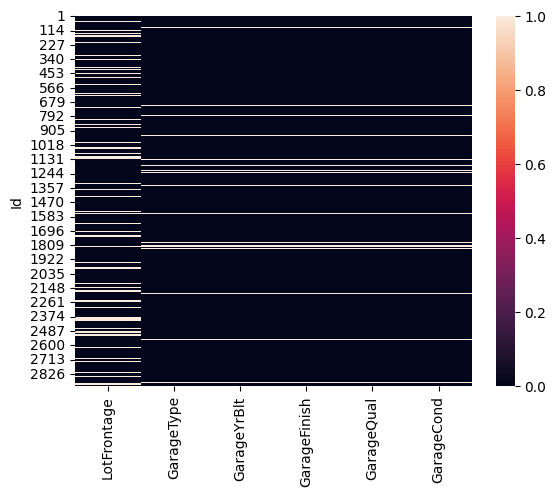

In [23]:
sns.heatmap(df[Null_val_5_20_pr.index].isnull())
plt.show()

# Missing Value Imputation 

In [24]:
Missing_val = null_value_per[null_value_per > 0]
print(f"Number of features with missing values: {len(Missing_val)}")

Number of features with missing values: 35


In [25]:
cat_na_feature = Missing_val[Missing_val.keys().isin(ob_feature)]
print(f"Number of categorical features with missing values: {len(cat_na_feature)}")
cat_na_feature

Number of categorical features with missing values: 23


MSZoning         0.137033
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665
Electrical       0.034258
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
dtype: float64

In [26]:
int_na_feature = Missing_val[Missing_val.keys().isin(int_feature)]
print(f"Number of integer features with missing values: {len(int_na_feature)}")
int_na_feature

Number of integer features with missing values: 0


Series([], dtype: float64)

In [27]:
float_na_feature = Missing_val[Missing_val.keys().isin(float_feature)]
print(f"Number of float features with missing values: {len(float_na_feature)}")
float_na_feature

Number of float features with missing values: 12


LotFrontage     16.649538
MasVnrArea       0.787941
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258
SalePrice       49.982871
dtype: float64

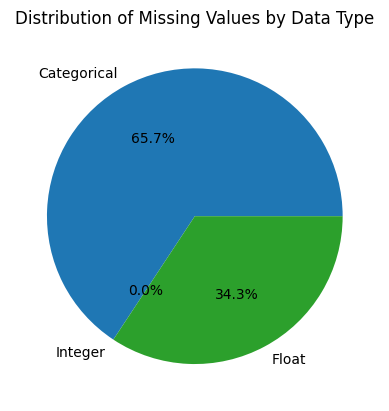

In [28]:
plt.pie([len(cat_na_feature), len(int_na_feature), len(float_na_feature)], labels=['Categorical', 'Integer', 'Float'], autopct='%1.1f%%')
plt.title("Distribution of Missing Values by Data Type")    
plt.savefig("E:\House Prise Prediction\EDA\missing_values_distribution.png")
plt.show()

# Handling MSZoning 0.137033

In [29]:
df['MSZoning'].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

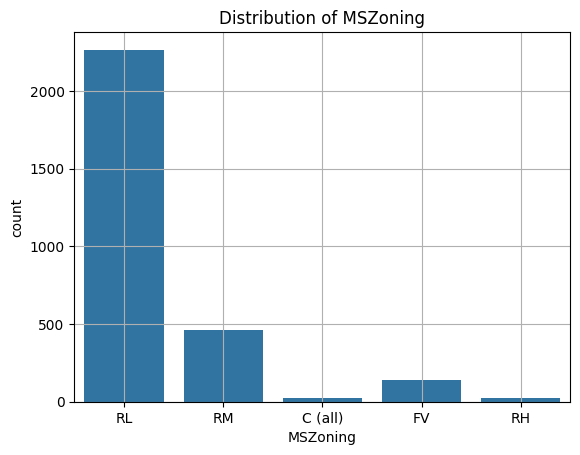

In [30]:
sns.countplot(x='MSZoning', data=df)
plt.title("Distribution of MSZoning")
plt.grid(True)

In [31]:
mszoning_mode = df['MSZoning'].mode()[0]
mszoning_mode

'RL'

In [32]:
## Backup of original data ##
df_mvi = df.copy() 
df_mvi.shape

(2919, 80)

In [33]:
mszoning_mode = df['MSZoning'].mode()[0]
df['MSZoning'].fillna(mszoning_mode, inplace=True)
df['MSZoning'].isnull().sum()

np.int64(0)

In [34]:
def oldNewCountPlot(df,df_new,feature):
    plt.subplot(121)
    sns.countplot(df[feature])
    plt.title("Before Imputation")
    plt.subplot(122)
    sns.countplot(df_new[feature])
    plt.title("After Imputation")
    

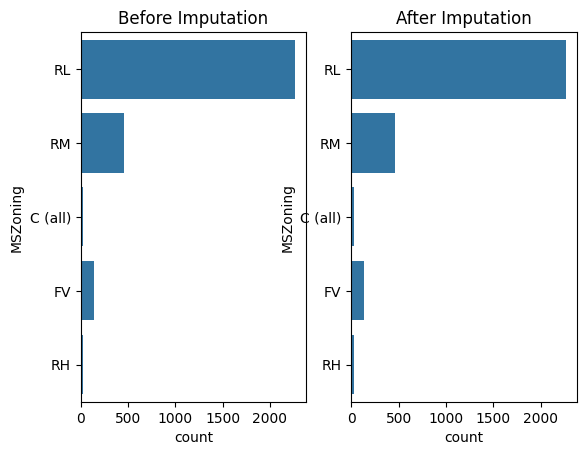

In [35]:
oldNewCountPlot(df, df_mvi, 'MSZoning')


In [36]:
## Handling Alley  93.216855
df_mvi['Alley'].value_counts() 

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [37]:
alley_count = 'NA'
df_mvi['Alley'].fillna(alley_count, inplace=True)
df_mvi['Alley'].isnull().sum()

np.int64(0)

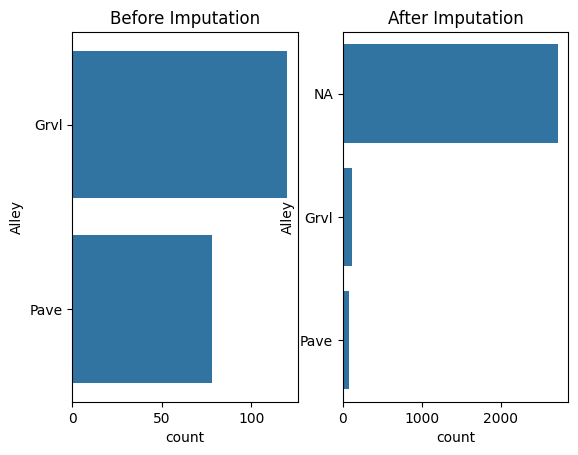

In [38]:
oldNewCountPlot(df, df_mvi, 'Alley')

In [39]:
## Handling LotFrontage  16.649538
df_mvi['LotFrontage'].value_counts()

LotFrontage
60.0     276
80.0     137
70.0     133
50.0     117
75.0     105
        ... 
155.0      1
126.0      1
200.0      1
131.0      1
133.0      1
Name: count, Length: 128, dtype: int64

In [40]:
def boxHistPlot(df, figsize=(16,5)):
    plt.figure(figsize=figsize)
    plt.subplot(121)
    sns.boxplot(df)
    plt.subplot(122)
    sns.distplot(df)
    

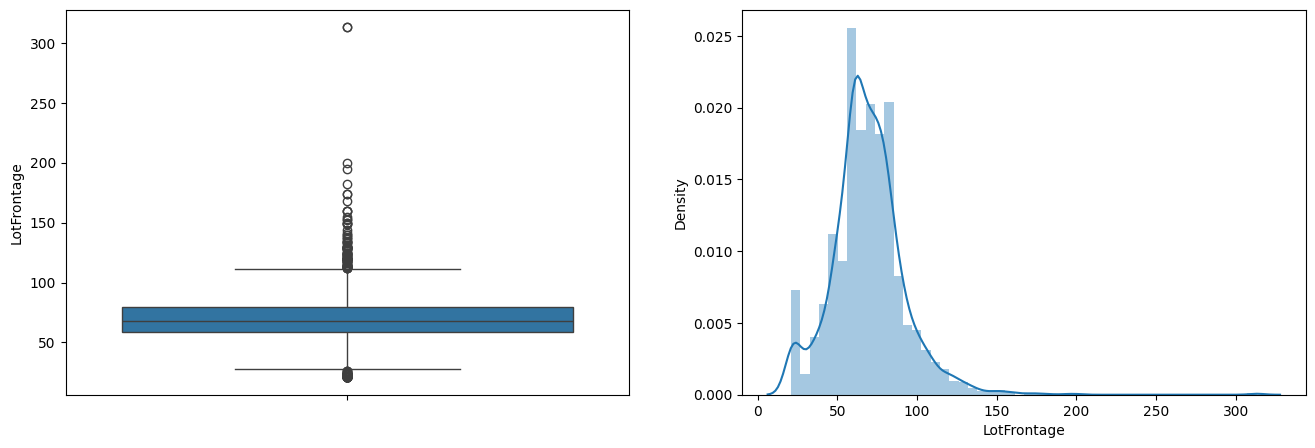

In [41]:
boxHistPlot(df['LotFrontage'])

In [42]:
lotfrontage_mean = df['LotFrontage'].mean()
df_mvi['LotFrontage'].replace(np.nan, lotfrontage_mean, inplace=True)
df_mvi['LotFrontage'].isnull().sum()

np.int64(0)

In [43]:
def oldnewBoxHistPlot(df, df_new,feature,figsize=(16,10)):
    plt.figure(figsize=figsize)
    plt.subplot(221)
    sns.boxplot(df[feature])
    plt.title("Before Imputation")
    plt.subplot(222)
    sns.distplot(df[feature])
    plt.title("Before Imputation")
    plt.subplot(223)
    sns.boxplot(df_new[feature])
    plt.title("After Imputation")
    plt.subplot(224)
    sns.distplot(df_new[feature])
    plt.title("After Imputation")
    

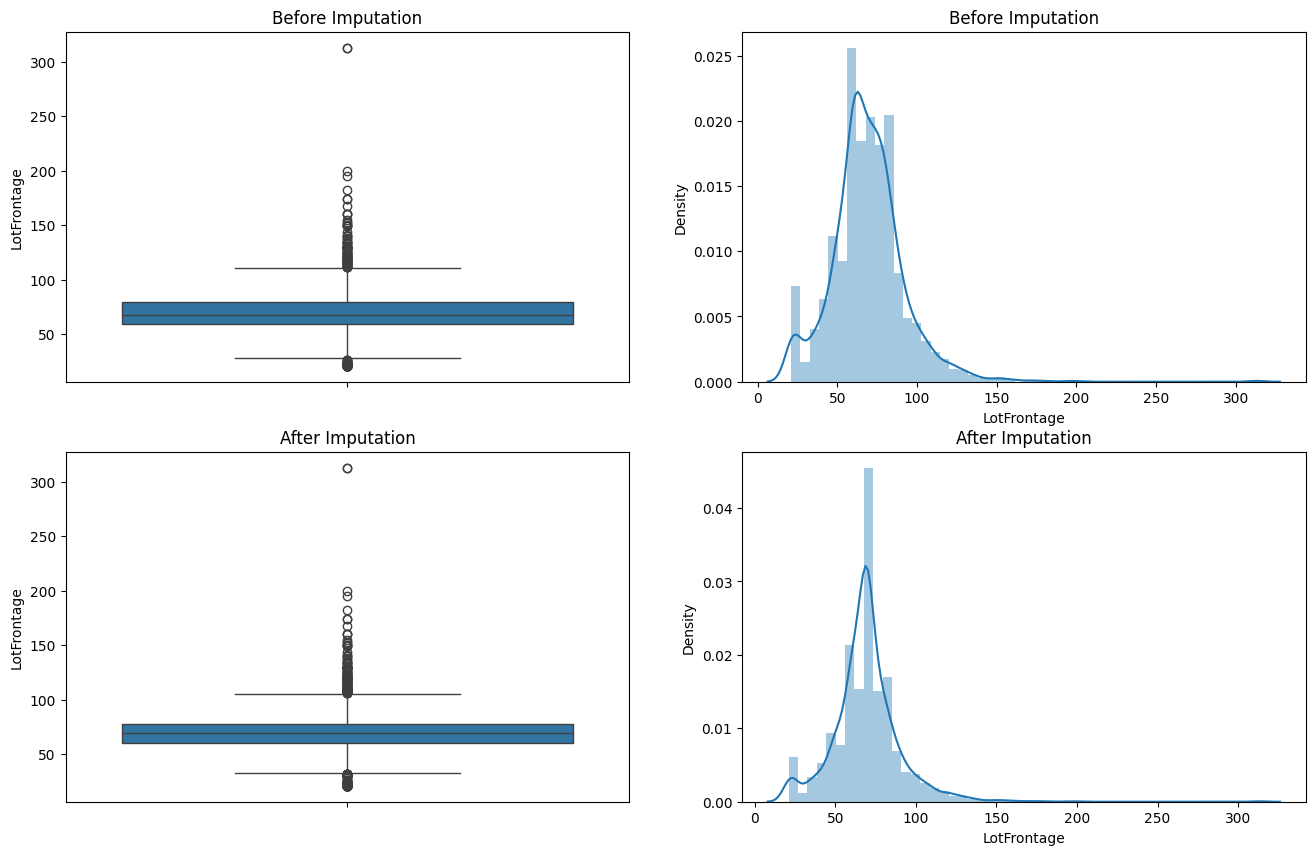

In [44]:
oldnewBoxHistPlot(df, df_mvi, 'LotFrontage')

In [45]:
## Handling Utilities  0.068517
df['Utilities'].value_counts()

Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64

In [46]:
utility_mode = df['Utilities'].mode()[0]
df_mvi['Utilities'].fillna(utility_mode, inplace=True)
df_mvi['Utilities'].isnull().sum()

np.int64(0)

## Handling Exterior1st = 0.034258 & Exterior2nd = 0.034258


In [47]:
df['Exterior1st'].value_counts()

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

In [48]:
df['Exterior2nd'].value_counts()

Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
Name: count, dtype: int64

In [49]:
Exterior1st_mode = df['Exterior1st'].mode()[0]
Exterior2nd_mode = df['Exterior2nd'].mode()[0]
df_mvi['Exterior1st'].fillna(Exterior1st_mode, inplace=True)
df_mvi['Exterior2nd'].fillna(Exterior2nd_mode, inplace=True)
print(df_mvi['Exterior1st'].isnull().sum())
print(df_mvi['Exterior2nd'].isnull().sum())

0
0


## Handling MasVnrType = 60.500171 & MasVnrArea = 0.061644

In [50]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [51]:
df['MasVnrArea'].value_counts()

MasVnrArea
0.0      1738
120.0      15
200.0      13
176.0      13
216.0      12
         ... 
355.0       1
405.0       1
327.0       1
257.0       1
382.0       1
Name: count, Length: 444, dtype: int64

<Axes: ylabel='Id'>

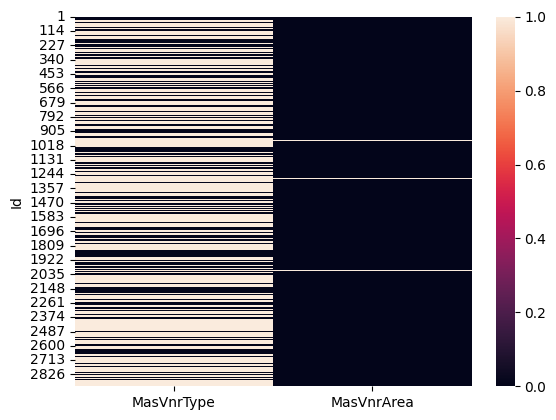

In [52]:
sns.heatmap(df[['MasVnrType','MasVnrArea']].isnull())


In [53]:
df[df[["MasVnrType","MasVnrArea"]].isnull().any(axis=1)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000.0
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900.0
10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,21.0,1526,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,NaN
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN


In [54]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [55]:
MasVnrType_mode = df['MasVnrType'].mode()[0]
df_mvi['MasVnrType'].fillna(MasVnrType_mode, inplace=True)
df_mvi['MasVnrType'].isnull().sum()

np.int64(0)

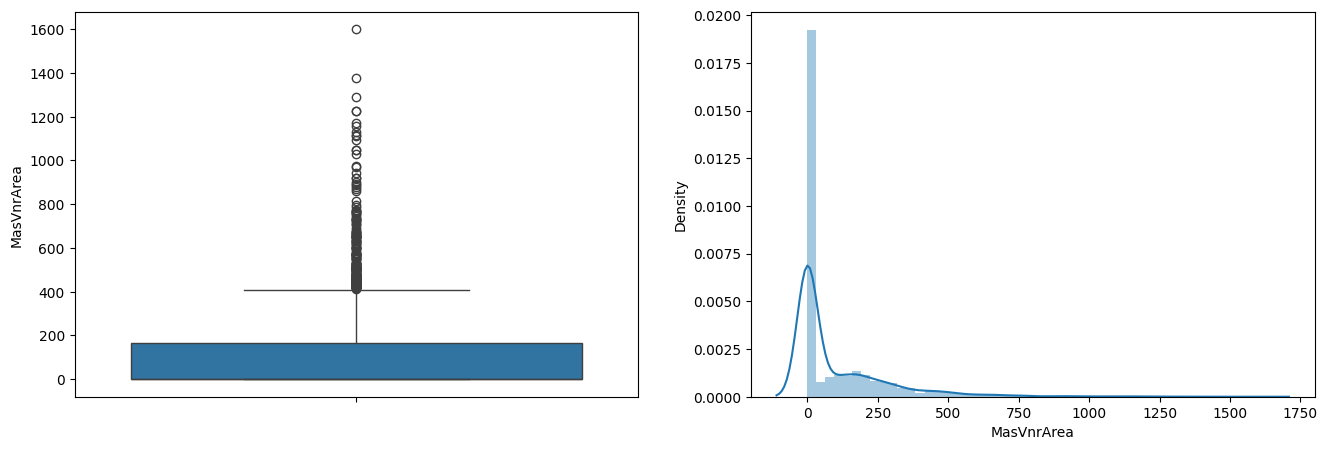

In [56]:
boxHistPlot(df['MasVnrArea'])

In [57]:
MasVnrArea_const = 0
df_mvi['MasVnrArea'].fillna(MasVnrArea_const, inplace=True)
df_mvi['MasVnrArea'].isnull().sum()

np.int64(0)

num_bas_feature = 
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517

cat_bas_feature = 
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665

In [58]:
num_bas_feature = [
"BsmtFinSF1",
"BsmtFinSF2",
"BsmtUnfSF",
"TotalBsmtSF",
"BsmtFullBath",
"BsmtHalfBath"
]

cat_bas_feature = [
"BsmtQual",
"BsmtCond",
"BsmtExposure",
"BsmtFinType1",
"BsmtFinType2"
]

<Axes: ylabel='Id'>

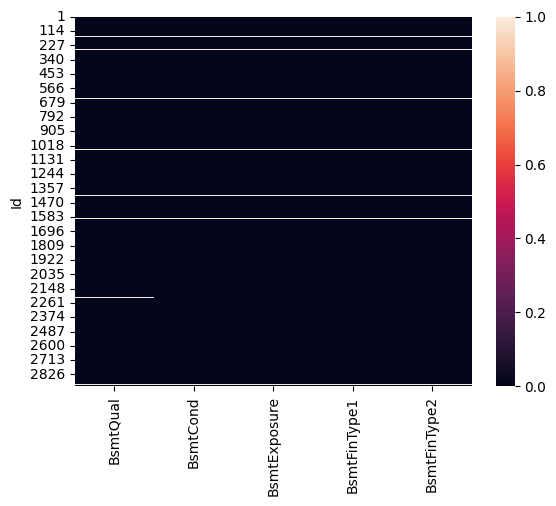

In [59]:
sns.heatmap(df[cat_bas_feature].isnull())

In [60]:
for feature in cat_bas_feature:
    print(f"Value counts for {feature}:\n{df[feature].value_counts()}\n")

Value counts for BsmtQual:
BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64

Value counts for BsmtCond:
BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64

Value counts for BsmtExposure:
BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64

Value counts for BsmtFinType1:
BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64

Value counts for BsmtFinType2:
BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64



In [61]:
bsmt_count = "NA"
for feature in cat_bas_feature:
    df_mvi[feature].fillna(bsmt_count, inplace=True)
    

In [62]:
df_mvi[cat_bas_feature].isnull().sum()

BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

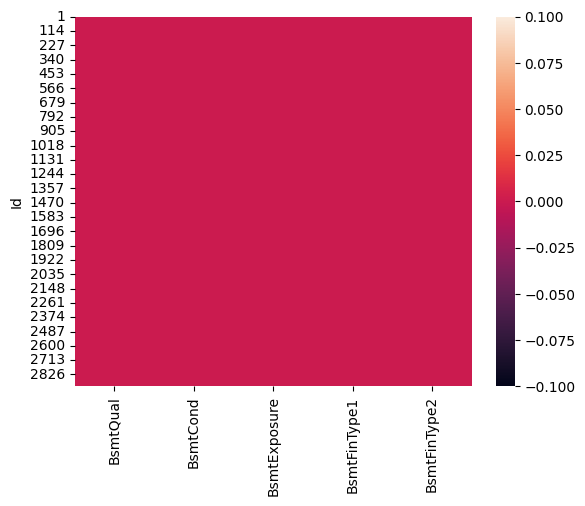

In [63]:
sns.heatmap(df_mvi[cat_bas_feature].isnull())
plt.show()

## Handling BSMT Features 

In [64]:
df_bsmt = df[cat_bas_feature + num_bas_feature]
df_bsmt[df_bsmt.isnull().any(axis=1)]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
Id,,,,,,,,,,,
18,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
40,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
91,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
103,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
157,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2804,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2805,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2825,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
bsmt_num = 0
for feature in num_bas_feature:
    df_mvi[feature].fillna(bsmt_num, inplace=True)


In [66]:
df_mvi[num_bas_feature].isnull().sum()

BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64

## Handling Electrical = 0.034258  &  KitchenQual = 0.034258 

In [67]:
df['Electrical'].value_counts()

Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [68]:
df["KitchenQual"].value_counts()

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64

In [69]:
df_ekk = df[['Electrical', 'KitchenQual','KitchenAbvGr']]
df_ekk[df_ekk.isnull().any(axis=1)]

,Electrical,KitchenQual,KitchenAbvGr
Id,,,
1380,NaN,Gd,1
1556,SBrkr,NaN,1


In [70]:
electrical_mode = df['Electrical'].mode()[0]
df_mvi['Electrical'].fillna(electrical_mode, inplace=True)
df_mvi['Electrical'].isnull().sum()

np.int64(0)

In [71]:
KitchenQual_mode = df['KitchenQual'].mode()[0]
df_mvi['KitchenQual'].fillna(KitchenQual_mode, inplace=True)
df_mvi['KitchenQual'].isnull().sum()

np.int64(0)

## Handling Remaining cat Features

Functional       0.068517 mode
FireplaceQu     48.646797 NA
PoolQC          99.657417 NA
Fence           80.438506 NA
MiscFeature     96.402878 NA
SaleType         0.034258 mode

In [72]:
df['Functional'].value_counts()

Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64

In [73]:
function_mode = df['Functional'].mode()[0]
df_mvi['Functional'].fillna(function_mode, inplace=True)
df_mvi['Functional'].isnull().sum()

np.int64(0)

In [74]:
df['SaleType'].value_counts()

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64

In [75]:
SaleType_mode = df['SaleType'].mode()[0]
df_mvi['SaleType'].fillna(SaleType_mode, inplace=True)
df_mvi['SaleType'].isnull().sum()

np.int64(0)

In [76]:
other_cat_feature = [
"FireplaceQu",
"PoolQC",
"Fence",
"MiscFeature"
]

for feature in other_cat_feature:
    print(f"Value counts for {feature}:\n{df[feature].value_counts()}\n")

Value counts for FireplaceQu:
FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64

Value counts for PoolQC:
PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64

Value counts for Fence:
Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64

Value counts for MiscFeature:
MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64



In [77]:
FireplaceQu_cont = 'NA'
df_mvi['FireplaceQu'].fillna(FireplaceQu_cont , inplace=True)
df_mvi['FireplaceQu'].isnull().sum()

np.int64(0)

In [78]:
PoolQC_cont = 'NA'
df_mvi['PoolQC'].fillna(PoolQC_cont , inplace=True)
df_mvi['PoolQC'].isnull().sum()

np.int64(0)

In [79]:
Fence_cont = 'NA'
df_mvi['Fence'].fillna(Fence_cont , inplace=True)
df_mvi['Fence'].isnull().sum()

np.int64(0)

In [80]:
MiscFeature_cont = 'NA'
df_mvi['MiscFeature'].fillna(MiscFeature_cont , inplace=True)
df_mvi['MiscFeature'].isnull().sum()

np.int64(0)

## Handling Garage Feature 

In [81]:
# GarageType       5.378554 NA
# GarageFinish     5.447071 NA
# GarageQual       5.447071 NA
# GarageCond       5.447071 NA

# GarageYrBlt      5.447071 0
# GarageCars       0.034258 0
# GarageArea       0.034258 0

In [82]:
cat_garage_feature = [
'GarageType',
'GarageFinish',
'GarageQual',
'GarageCond'
]
num_garage_feature = [
'GarageYrBlt',
'GarageCars',   
'GarageArea'
]   

df_garage = df[num_garage_feature + cat_garage_feature]
df_garage[df_garage.isnull().any(axis=1)]

,GarageYrBlt,GarageCars,GarageArea,GarageType,GarageFinish,GarageQual,GarageCond
Id,,,,,,,
40,NaN,0.0,0.0,NaN,NaN,NaN,NaN
49,NaN,0.0,0.0,NaN,NaN,NaN,NaN
79,NaN,0.0,0.0,NaN,NaN,NaN,NaN
89,NaN,0.0,0.0,NaN,NaN,NaN,NaN
90,NaN,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2894,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2910,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2914,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [83]:
garage_cont = 'NA'
for feature in cat_garage_feature:
    df_mvi[feature].fillna(garage_cont , inplace=True)
df_mvi[cat_garage_feature].isnull().sum()

GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64

In [84]:
garage_num = 0
for feature in num_garage_feature:
    df_mvi[feature].fillna(garage_num, inplace=True)
df_mvi[num_garage_feature].isnull().sum()

GarageYrBlt    0
GarageCars     0
GarageArea     0
dtype: int64

In [85]:
df_mvi.isnull().any(axis=1).sum()

np.int64(1459)

## Feature Transforming
## Convert Numerical Feature to Categorical Feature


In [86]:
# MSSubclass , YearBuild , YearRemodAdd , YearGarageBuilt , GarageYrBlt , MoSold , YrSold 

In [87]:
for_num_conv = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
for feature in for_num_conv:
    print(f"{feature} : data type = {df_mvi[feature].dtype}")

MSSubClass : data type = int64
YearBuilt : data type = int64
YearRemodAdd : data type = int64
GarageYrBlt : data type = float64
MoSold : data type = int64
YrSold : data type = int64


In [88]:
df_mvi[for_num_conv].head()

,MSSubClass,YearBuilt,YearRemodAdd,GarageYrBlt,MoSold,YrSold
Id,,,,,,
1,60,2003,2003,2003.0,2,2008
2,20,1976,1976,1976.0,5,2007
3,60,2001,2002,2001.0,9,2008
4,70,1915,1970,1998.0,2,2006
5,60,2000,2000,2000.0,12,2008


In [89]:
df_mvi['MoSold'].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6])

In [90]:
calendar.month_abbr[1:13]

['Jan',
 'Feb',
 'Mar',
 'Apr',
 'May',
 'Jun',
 'Jul',
 'Aug',
 'Sep',
 'Oct',
 'Nov',
 'Dec']

In [91]:
df_mvi['MoSold'] = df_mvi['MoSold'].apply(lambda x: calendar.month_abbr[x])

In [92]:
df_mvi['MoSold']

Id
1       Feb
2       May
3       Sep
4       Feb
5       Dec
       ... 
2915    Jun
2916    Apr
2917    Sep
2918    Jul
2919    Nov
Name: MoSold, Length: 2919, dtype: object

In [93]:
for feature in for_num_conv:
    df_mvi[feature] = df_mvi[feature].astype(str)

In [94]:
for feature in for_num_conv:
    print(f"{feature} : data type = {df_mvi[feature].dtype}")

MSSubClass : data type = object
YearBuilt : data type = object
YearRemodAdd : data type = object
GarageYrBlt : data type = object
MoSold : data type = object
YrSold : data type = object


## Convert Categorical Feature into Numerical  Feature 

## Ordinal Encoding 

In [95]:
ordinal_feature = [
"ExterQual",
"ExterCond",    
"BsmtQual",
"BsmtCond",
"BsmtExposure",
"BsmtFinType1",
"BsmtFinSF1",
"BsmtFinType2",
"HeatingQC",    
"KitchenQual",
"FireplaceQu",
"GarageQual",
"GarageCond",
"PoolQC",
"Functional",
"GarageFinish",
"PavedDrive",
"Utilities"
]
print("Total number of feature to convert into ordinal: ", len(ordinal_feature))

Total number of feature to convert into ordinal:  18


In [96]:
df_mvi["ExterQual"].value_counts()

ExterQual
TA    1798
Gd     979
Ex     107
Fa      35
Name: count, dtype: int64

In [97]:
from pandas.api.types import CategoricalDtype

In [98]:
CategoricalDtype

df_mvi["ExterQual"] = df_mvi["ExterQual"].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes

In [99]:
df_mvi['MSSubClass'].value_counts()

MSSubClass
20     1079
60      575
50      287
120     182
30      139
70      128
160     128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64

In [100]:
df_mvi["ExterQual"].value_counts()

ExterQual
2    1798
3     979
4     107
1      35
Name: count, dtype: int64

In [101]:
df_mvi["BsmtExposure"].value_counts()

BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
NA      82
Name: count, dtype: int64

In [102]:
df_mvi["BsmtExposure"] = df_mvi["BsmtExposure"].astype(CategoricalDtype(categories=['NA','No','Mn','Av','Gd'], ordered=True)).cat.codes

In [103]:
df_mvi["BsmtExposure"].value_counts()

BsmtExposure
1    1904
3     418
4     276
2     239
0      82
Name: count, dtype: int64

In [104]:
df_mvi["ExterCond"].value_counts()

ExterCond
TA    2538
Gd     299
Fa      67
Ex      12
Po       3
Name: count, dtype: int64

In [105]:
df_mvi["ExterCond"] = df_mvi["ExterCond"].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["BsmtQual"] = df_mvi["BsmtQual"].astype(CategoricalDtype(categories=['NA','Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["BsmtCond"] = df_mvi["BsmtCond"].astype(CategoricalDtype(categories=['NA','Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["BsmtFinType1"] = df_mvi["BsmtFinType1"].astype(CategoricalDtype(categories=['NA','Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], ordered=True)).cat.codes
df_mvi["BsmtFinSF1"] = df_mvi["BsmtFinSF1"].astype(CategoricalDtype(categories=['NA','Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], ordered=True)).cat.codes
df_mvi["BsmtFinType2"] = df_mvi["BsmtFinType2"].astype(CategoricalDtype(categories=['NA','Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], ordered=True)).cat.codes
df_mvi["HeatingQC"] = df_mvi["HeatingQC"].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["KitchenQual"] = df_mvi["KitchenQual"].astype(CategoricalDtype(categories=['Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["FireplaceQu"] = df_mvi["FireplaceQu"].astype(CategoricalDtype(categories=['NA','Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["GarageQual"] = df_mvi["GarageQual"].astype(CategoricalDtype(categories=['NA','Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["GarageCond"] = df_mvi["GarageCond"].astype(CategoricalDtype(categories=['NA','Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["PoolQC"] = df_mvi["PoolQC"].astype(CategoricalDtype(categories=['NA','Po', 'Fa', 'TA', 'Gd', 'Ex'], ordered=True)).cat.codes
df_mvi["Functional"] = df_mvi["Functional"].astype(CategoricalDtype(categories=['NA','Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'], ordered=True)).cat.codes
df_mvi["GarageFinish"] = df_mvi["GarageFinish"].astype(CategoricalDtype(categories=['NA','Unf', 'RFn', 'Fin'], ordered=True)).cat.codes
df_mvi["PavedDrive"] = df_mvi["PavedDrive"].astype(CategoricalDtype(categories=['NA','N', 'P', 'Y'], ordered=True)).cat.codes
df_mvi["Utilities"] = df_mvi["Utilities"].astype(CategoricalDtype(categories=['NA','ELO', 'NoSeWa', 'NoSewr', 'AllPub'], ordered=True)).cat.codes

In [106]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   int8   
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

In [107]:
df_mvi['MSZoning'].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

In [108]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2915 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   int8   
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

## One Hot Encoding for Numerical Categorical Data 

In [109]:
df_encod = df_mvi.copy()

object_features = df_encod.select_dtypes(include="object").columns.tolist()
print("Total Object Datatype features : ",(len(object_features)))

print("Features : \n",object_features)

Total Object Datatype features :  32
Features : 
 ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'GarageYrBlt', 'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [110]:
df_encod[object_features].head(2)

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,CentralAir,Electrical,GarageType,GarageYrBlt,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,Pave,NA,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,Y,SBrkr,Attchd,2003.0,NA,NA,Feb,2008,WD,Normal
2,20,RL,Pave,NA,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,Y,SBrkr,Attchd,1976.0,NA,NA,May,2007,WD,Normal


In [111]:
print("The shape of data before encoding: ", df_encod.shape)
df_encod = pd.get_dummies(df_encod, columns= object_features , prefix =object_features, drop_first=True)
print("The shape of data after encoding: ", df_encod.shape)

The shape of data before encoding:  (2919, 80)
The shape of data after encoding:  (2919, 512)


In [112]:
print(df_encod.columns)

Index(['LotFrontage', 'LotArea', 'Utilities', 'OverallQual', 'OverallCond',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=512)


In [113]:
df_encod.filter(like="MSZoning").sum()

MSZoning_FV     139
MSZoning_RH      26
MSZoning_RL    2265
MSZoning_RM     460
dtype: int64

In [114]:
[col for col in df_encod.columns if "MSZoning" in col]

['MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM']

In [115]:
df_encod.head()

,LotFrontage,LotArea,Utilities,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,4,7,5,196.0,3,2,4,3,...,False,False,False,False,True,False,False,False,True,False
2,80.0,9600,4,6,8,0.0,2,2,4,3,...,False,False,False,False,True,False,False,False,True,False
3,68.0,11250,4,7,5,162.0,3,2,4,3,...,False,False,False,False,True,False,False,False,True,False
4,60.0,9550,4,7,5,0.0,2,2,3,4,...,False,False,False,False,True,False,False,False,False,False
5,84.0,14260,4,8,5,350.0,3,2,4,3,...,False,False,False,False,True,False,False,False,True,False


In [116]:
df_encod.select_dtypes(include="object").columns.tolist()

[]

## Split Data for Training & Testing

In [117]:
df_encod.shape

(2919, 512)

In [118]:
len_train = df_train.shape[0]
len_train

1460

In [119]:
X_train = df_encod[:len_train].drop("SalePrice", axis=1)
Y_train = df_encod[:len_train]["SalePrice"]

X_test = df_encod[len_train:].drop("SalePrice", axis=1)

print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (1460, 511)
Shape of Y_train:  (1460,)
Shape of X_test:  (1459, 511)


## Feature Scalling

In [120]:
from sklearn.preprocessing import StandardScaler

In [121]:
scaler = StandardScaler()
scaler.fit(X_train) 

# Formula = z = (x-u)/s

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [122]:
X_train[:3,:]

array([[-0.22335706, -0.20714171,  0.02618016, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.45789401, -0.09188637,  0.02618016, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.08710685,  0.07347998,  0.02618016, ..., -0.11785113,
         0.4676514 , -0.30599503]], shape=(3, 511))

In [123]:
X_test[:3,:]

array([[ 0.45789401,  0.11076257,  0.02618016, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.50331075,  0.37584985,  0.02618016, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.18539358,  0.33205282,  0.02618016, ..., -0.11785113,
         0.4676514 , -0.30599503]], shape=(3, 511))

In [124]:
# Carry forward fordeployment

# scaler.mean_.shape
# scaler.with_std
# scaler.n_features_in_
# scaler.n_samples_seen_
# scaler.with_mean

## Train ML Model

In [125]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression

from sklearn.linear_model import SGDRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

In [127]:
SVR = SVR()
LR = LinearRegression()
SGD = SGDRegressor()
KNN = KNeighborsRegressor()
GPR = GaussianProcessRegressor()
DTR = DecisionTreeRegressor()
GBR = GradientBoostingRegressor()
RFR = RandomForestRegressor()
MLP = MLPRegressor()
XGB = XGBRegressor()



In [128]:
models = {
    "a" : ["LinearRegression",LR],
    "b" : ["SGDRegressor",SGD],
    "c" : ["KNeighborsRegressor",KNN],
    "d" : ["GaussianProcessRegressor",GPR],
    "e" : ["DecisionTreeRegressor",DTR],
    "f" : ["GradientBoostingRegressor",GBR],
    "g" : ["RandomForestRegressor",RFR],
    "h" : ["MLPRegressor",MLP],
    "i" : ["XGBRegressor",XGB]
}

In [129]:
from sklearn.model_selection import cross_val_score,KFold
from sklearn.metrics import make_scorer, r2_score

def test_model(models, X_train=X_train, Y_train=Y_train):
    cv = KFold(n_splits = 7 , shuffle = True, random_state = 42)
    r2 = make_scorer(r2_score)
    r2_val_score = cross_val_score(models, X_train , Y_train , cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score

In [130]:
models_score = []
for model in models:
    print("Training model :", models[model][0])
    score = test_model(models[model][1],X_train, Y_train)
    print("Score of model : ", score)
    models_score.append((models[model][0], score[0]))

Training model : LinearRegression
Score of model :  [np.float64(0.5924387940392292)]
Training model : SGDRegressor
Score of model :  [np.float64(-2782.887338161595)]
Training model : KNeighborsRegressor
Score of model :  [np.float64(0.5652710881985612)]
Training model : GaussianProcessRegressor
Score of model :  [np.float64(-5.333036722858856)]
Training model : DecisionTreeRegressor
Score of model :  [np.float64(0.7059186413181798)]
Training model : GradientBoostingRegressor
Score of model :  [np.float64(0.8485864459172312)]
Training model : RandomForestRegressor
Score of model :  [np.float64(0.8421509949565177)]
Training model : MLPRegressor
Score of model :  [np.float64(-4.769342910001005)]
Training model : XGBRegressor
Score of model :  [np.float64(0.822448697824052)]


In [131]:
models_score

[('LinearRegression', np.float64(0.5924387940392292)),
 ('SGDRegressor', np.float64(-2782.887338161595)),
 ('KNeighborsRegressor', np.float64(0.5652710881985612)),
 ('GaussianProcessRegressor', np.float64(-5.333036722858856)),
 ('DecisionTreeRegressor', np.float64(0.7059186413181798)),
 ('GradientBoostingRegressor', np.float64(0.8485864459172312)),
 ('RandomForestRegressor', np.float64(0.8421509949565177)),
 ('MLPRegressor', np.float64(-4.769342910001005)),
 ('XGBRegressor', np.float64(0.822448697824052))]

In [132]:
final_model = XGBRegressor()
final_model.fit(X_train, Y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Save Trained Model

In [133]:
import joblib

if 'final_model' in globals():
    joblib.dump(final_model, 'House_Price_Prediction_Model.pkl')
else:
    print("final_model is not defined. Run the training cells before saving.")

if 'scaler' in globals():
    joblib.dump(scaler, 'House_Price_Prediction_Scaler.pkl')
else:
    print("scaler is not defined. Run the scaling cells before saving.")

if 'df_encod' in globals():
    feature_names = df_encod.drop("SalePrice", axis=1).columns.tolist()
    joblib.dump(feature_names, 'House_Price_Prediction_Columns.pkl')
else:
    print("df_encod is not defined. Run the preprocessing cells before saving feature columns.")

In [134]:
# Final prediction and submission export
if 'X_test' in globals() and 'final_model' in globals() and 'df_test' in globals():
    predictions = final_model.predict(X_test)
    submission = pd.DataFrame({
        'Id': df_test['Id'],
        'SalePrice': predictions
    })
    submission.to_csv('submission.csv', index=False)
    print('submission.csv created with shape:', submission.shape)
else:
    print('Missing required data to create submission. Run the preprocessing and model training cells first.')

submission.csv created with shape: (1459, 2)
